In [1]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Number of users
n = 10000

# Create user IDs
user_ids = np.arange(1, n + 1)

# Randomly assign variants (50/50 split)
variants = np.random.choice(['A', 'B'], size=n, p=[0.5, 0.5])

# Define realistic conversion rates
p_A = 0.08   # 8% conversion for control
p_B = 0.095  # 9.5% conversion for new CTA (a modest lift)

# Simulate conversions based on variant
conversions = [
    np.random.binomial(1, p_A) if v == 'A' else np.random.binomial(1, p_B)
    for v in variants
]

# Build DataFrame
df = pd.DataFrame({
    'user_id': user_ids,
    'variant': variants,
    'converted': conversions
})

# Show first few rows
df.head()


,user_id,variant,converted
0,1,A,0
1,2,B,0
2,3,B,0
3,4,B,0
4,5,A,0


In [18]:
df.to_csv("cta_ab_test_data.csv", index=False)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [10]:
df.info()
#df.describe(include='all')
#df['variant'].value_counts(normalize=True)
#df['converted'].mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    10000 non-null  int64 
 1   variant    10000 non-null  object
 2   converted  10000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 234.5+ KB


In [11]:
conversion_rates = df.groupby('variant')['converted'].mean()
conversion_rates

variant
A    0.083530
B    0.095857
Name: converted, dtype: float64

C:\Users\jdshu\AppData\Local\Temp\ipykernel_13060\889903696.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


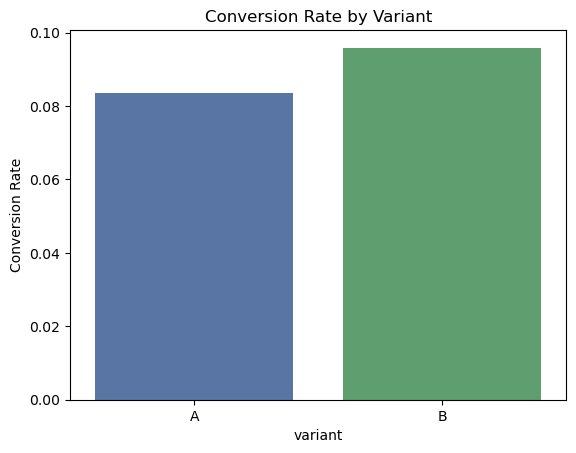

In [12]:
sns.barplot(
    x=conversion_rates.index,
    y=conversion_rates.values,
    palette=['#4C72B0', '#55A868']
)
plt.title("Conversion Rate by Variant")
plt.ylabel("Conversion Rate")
plt.show()

In [13]:
# Count conversions
conversions = df.groupby('variant')['converted'].sum()
samples = df.groupby('variant')['converted'].count()

# Prepare inputs
successes = [conversions['A'], conversions['B']]
nobs = [samples['A'], samples['B']]

# Run z-test
z_stat, p_value = proportions_ztest(successes, nobs)
z_stat, p_value

(np.float64(-2.1577250410904454), np.float64(0.03094921584137228))

In [14]:
ci_low_A, ci_upp_A = proportion_confint(conversions['A'], samples['A'], alpha=0.05)
ci_low_B, ci_upp_B = proportion_confint(conversions['B'], samples['B'], alpha=0.05)

ci_low_A, ci_upp_A, ci_low_B, ci_upp_B

(0.07591887038776603,
 0.09114180731120954,
 0.08763422918233574,
 0.10407982443261146)

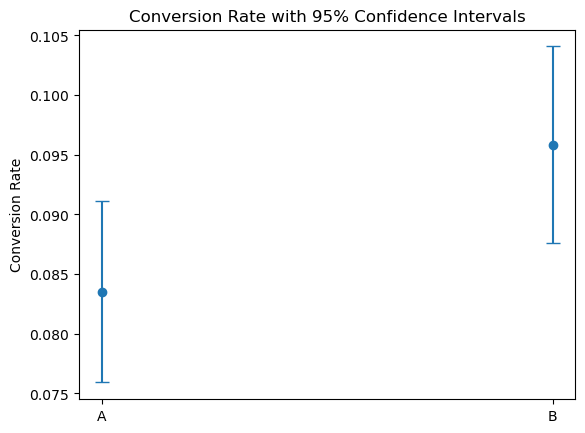

In [15]:
plt.errorbar(
    x=['A', 'B'],
    y=conversion_rates.values,
    yerr=[
        conversion_rates.values - np.array([ci_low_A, ci_low_B]),
        np.array([ci_upp_A, ci_upp_B]) - conversion_rates.values
    ],
    fmt='o',
    capsize=5
)
plt.title("Conversion Rate with 95% Confidence Intervals")
plt.ylabel("Conversion Rate")
plt.show()

In [16]:
cr_A = conversion_rates['A']
cr_B = conversion_rates['B']

lift = (cr_B - cr_A) / cr_A
lift

np.float64(0.14757138696871702)

In [17]:
from statsmodels.stats.power import zt_ind_solve_power

effect_size = cr_B - cr_A
power = zt_ind_solve_power(
    effect_size=effect_size,
    nobs1=samples['A'],
    alpha=0.05,
    ratio=1.0,
    alternative='two-sided'
)
power

np.float64(0.09521757166533375)

Summary of Results
Variant A conversion rate: 8.35%

Variant B conversion rate: 9.59%

Lift: 14.76%

p‑value: 0.03

Statistical significance: Yes

Confidence intervals: The test reached statistical significance, but overlapping confidence intervals suggest the improvement is small and may not translate into a meaningful business impact without further validation.

Recommendation: Variant B’s CTA shows a statistically significant improvement in conversion rate. The confidence intervals slightly overlap, which means the lift is modest, but the direction is clearly positive. I recommend rolling out Variant B to all traffic and keeping an eye on performance as it scales.